In [10]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pydicom import dcmread
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from pydose_rt import DoseEngine
from pydose_rt.data import MachineConfig, Phantom, Beam

In [2]:
machine_config = MachineConfig(field_size=(100, 100), number_of_leaf_pairs=10, tpr_20_10=0.73, mean_photon_energy_MeV=0.39)
phantom = Phantom.from_uniform_water(shape=(185, 167, 167), spacing=(3.0, 3.0, 3.0))
beam = Beam.create(
    gantry_angle_deg=0.0,
    number_of_leaf_pairs=10, 
    field_size_mm=(100.0, 100.0),
    iso_center=(0.0, 150, 0.0)
)

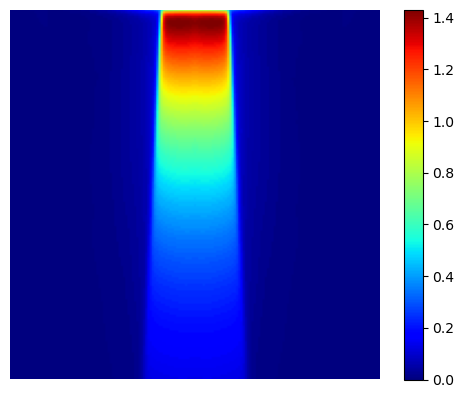

In [ ]:
slice_idx = 92
ds_ref = np.load("../example_data/water_phantom.npz")["dose"] / 100
plt.imshow(ds_ref[slice_idx, :, :], cmap='jet')
plt.axis('off')
plt.colorbar()
plt.show()

In [4]:
phantom.ct_array.shape

torch.Size([185, 167, 167])

In [6]:
dose_layer = DoseEngine(
    ct_array_shape=phantom.ct_array.shape, 
    resolution=phantom.voxel_spacing_mm, 
    machine_config=machine_config,
    beam_input=beam, 
    kernel_size=151, 
    dtype=torch.float32, 
    device=device)
phantom = phantom.to(dose_layer.dtype).to(dose_layer.device)
dose = dose_layer.compute_single_beam(beam, ct_image=phantom.ct_array).detach().cpu().numpy()

/home/bolo/Documents/PyDoseRT/src/pydose_rt/geometry/projections.py:69: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


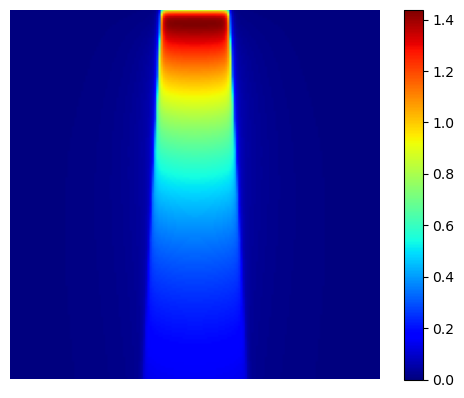

In [7]:
plt.imshow(dose[0, slice_idx, :, :], cmap='jet', vmin=np.min(dose), vmax=np.max(dose)) #, alpha=0.5)
plt.axis('off')
plt.colorbar()
# plt.axis('off')
plt.show()

(1, 185, 167, 167)
(185, 167, 167)


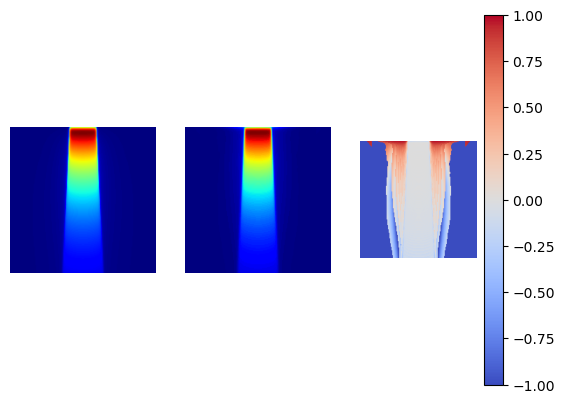

In [8]:
slice_idx = 84
print(dose.shape)
print(ds_ref.shape)

dose_plot = dose
plt.subplot(131)
plt.imshow(dose_plot[0, slice_idx, :, :], cmap='jet')
plt.axis('off')
plt.subplot(132)
plt.imshow(ds_ref[slice_idx, :, :], cmap='jet')
plt.axis('off')
plt.subplot(133)
plt.imshow((ds_ref[slice_idx, :, :] - dose_plot[0, slice_idx, :, :]) / (ds_ref[slice_idx, :, :] + 1e-10), cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.axis('off')
plt.show()

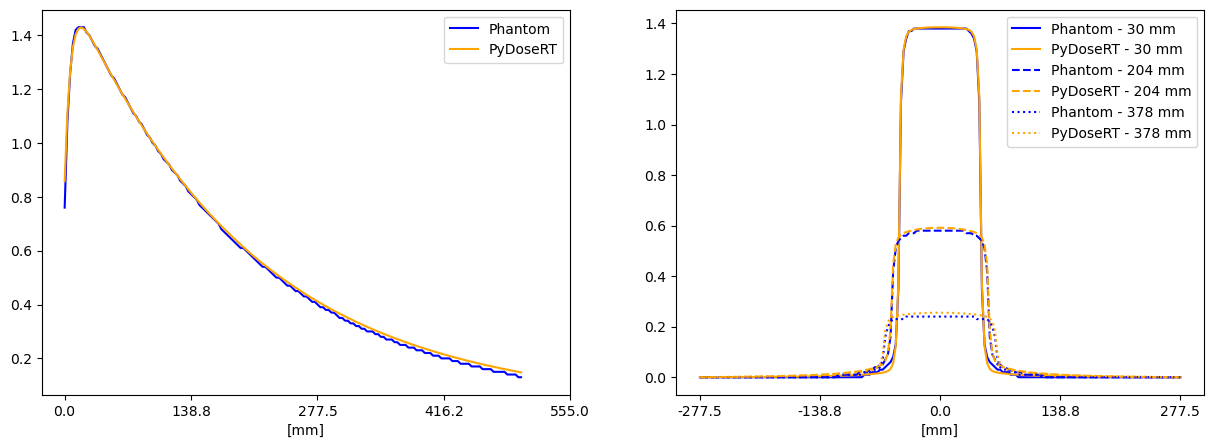

In [9]:
air_gap = 1

slice_idx = 84
depth_index = 93

x = np.linspace(0, dose_layer.ct_array_shape[1], dose_layer.ct_array_shape[1])

plt.figure(figsize=(15, 5))
# Create the plot
plt.subplot(121)
plt.plot(x, ds_ref[slice_idx, :, depth_index], label='Phantom', color='blue')
plt.plot(x, dose_plot[0, slice_idx, :, depth_index], label='PyDoseRT', color='orange')
plt.legend()

# Set x-ticks from 0 to 128, but label them as 0 to 26
num_ticks = 5
new_xticks = np.linspace(0, dose_layer.ct_array_shape[0], num_ticks)  # 27 points from 0 to 128
new_xtick_labels = np.round(np.linspace(0, dose_layer.ct_array_shape[0]*dose_layer.resolution[0], num_ticks), 1)  # Corresponding labels from 0 to 26

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[mm]')

plt.subplot(122)

num_ticks = 5
new_xticks = np.linspace(0, dose_layer.ct_array_shape[0], num_ticks)  # 27 points from 0 to 128
new_xtick_labels = np.round(np.linspace(-dose_layer.ct_array_shape[0]*dose_layer.resolution[0] / 2, dose_layer.ct_array_shape[0]*dose_layer.resolution[0] / 2, num_ticks), 1)  # Corresponding labels from 0 to 26
x = np.linspace(0, dose_layer.ct_array_shape[0], dose_layer.ct_array_shape[0])

# Create the plot
slices = np.linspace(10, dose_layer.ct_array_shape[0], 3, endpoint=False).astype(int)
line_styles = ['-', '--', ':']
for i in range(len(slices)):
  plt.plot(x, ds_ref[:, slices[i], depth_index], label=f'Phantom - {int(slices[i] * dose_layer.resolution[1])} mm', color='blue', linestyle=line_styles[i])
  plt.plot(x, dose_plot[0, :, slices[i], depth_index], label=f'PyDoseRT - {int(slices[i] * dose_layer.resolution[1])} mm', color='orange', linestyle=line_styles[i])
plt.legend()

# Apply the new ticks and labels
plt.xticks(new_xticks, new_xtick_labels)
plt.xlabel('[mm]')

# Show the plot
plt.show()